# **Caso People Analytics II - Strategic Attrition Intelligence**

Reducción de rotación voluntaria e involuntaria no deseada en talento crítico.

Una empresa tecnológica de 350 empleados presenta una rotación total cercana al 20%, afectando especialmente a perfiles técnicos senior y talento de alto rendimiento.

La organización quiere:
- Identificar los principales drivers de salida.
- Detectar talento crítico en riesgo.
- Construir un modelo predictivo de rotación.
- Estimar el impacto financiero de la rotación.
- Definir acciones preventivas basadas en datos.

In [93]:
# Definimos las librerias de pyhton que vamos a utilizar

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [94]:
# Cargamos el Dataset que usaremos

url = "https://raw.githubusercontent.com/Pablolg87/people-analytics-case-02-strategic-attrition-intelligence/refs/heads/main/strategic_attrition_dataset.csv"
employees = pd.read_csv(url)

In [95]:
# Miramos como es:

employees.info()

employees.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 355 entries, 0 to 354
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   employee_id             355 non-null    int64  
 1   department              355 non-null    object 
 2   seniority               355 non-null    object 
 3   manager_id              345 non-null    float64
 4   age                     355 non-null    int64  
 5   tenure_years            355 non-null    float64
 6   salary                  355 non-null    int64  
 7   salary_band_min         355 non-null    int64  
 8   salary_band_max         355 non-null    int64  
 9   performance_score       340 non-null    float64
 10  months_since_promotion  343 non-null    float64
 11  engagement_score        335 non-null    float64
 12  training_hours          355 non-null    int64  
 13  attrition               355 non-null    int64  
dtypes: float64(5), int64(7), object(2)
memory 

,employee_id,department,seniority,manager_id,age,tenure_years,salary,salary_band_min,salary_band_max,performance_score,months_since_promotion,engagement_score,training_hours,attrition
0,1,Sales,Mid,11.0,45,0.82,66041,47153,76494,7.0,86.0,2.5,6,0
1,2,HR,Senior,3.0,59,6.80,53384,30780,78551,NaN,7.0,6.1,42,0
2,3,Data,Mid,1.0,29,6.55,30145,39908,55612,0.0,81.0,7.9,53,0
3,4,Product,Junior,6.0,42,2.73,67778,36303,69203,0.0,11.0,5.5,23,0
4,5,Engineering,Junior,NaN,24,9.51,46035,44686,72071,9.0,30.0,1.1,3,1
5,6,Engineering,Mid,24.0,46,-0.80,33040,33983,75074,2.0,77.0,1.1,27,0
6,7,Engineering,Junior,10.0,49,4.32,72422,39503,57307,8.0,33.0,NaN,14,0
7,8,HR,Mid,5.0,54,9.44,56160,46905,62133,6.0,81.0,9.3,0,0
8,9,Product,Senior,23.0,43,4.20,47633,43070,66205,1.0,97.0,3.1,54,0
9,10,Data,Mid,10.0,57,6.39,59344,42232,77893,8.0,74.0,6.7,2,0


Hacemos un EDA y "limpiamos" los datos:

In [96]:
# Comprobamos duplicados:

employees.duplicated().sum()

np.int64(5)

In [97]:
# Los eliminamos:

employees.drop_duplicates(inplace=True)

In [98]:
# Comprobamos valores nulos

employees.isna().sum()

,0
employee_id,0
department,0
seniority,0
manager_id,10
age,0
tenure_years,0
salary,0
salary_band_min,0
salary_band_max,0
performance_score,15


In [99]:
# Realizamos las siguientes acciones para resolverlo:

# 1) Flags: guardamos si el valor venía vacío (NaN)
employees["engagement_missing"]  = employees["engagement_score"].isna().astype(int)
employees["performance_missing"] = employees["performance_score"].isna().astype(int)
employees["promotion_missing"]   = employees["months_since_promotion"].isna().astype(int)
employees["manager_missing"]     = employees["manager_id"].isna().astype(int)

# 2) Engagement: rellenamos nulos con la mediana (valor típico robusto)
employees["engagement_score"] = employees["engagement_score"].fillna(
    employees["engagement_score"].median()
)

# 3) Performance (0–10): rellenamos nulos con mediana y limitamos el rango
employees["performance_score"] = employees["performance_score"].fillna(
    employees["performance_score"].median()
)
employees["performance_score"] = employees["performance_score"].clip(0, 10)

# 4) Months since promotion: si falta, usamos tenure en meses como aproximación
employees["months_since_promotion"] = employees["months_since_promotion"].fillna(
    employees["tenure_years"] * 12
)

# 5) Manager: si falta, lo ponemos a 0 (y ya tenemos el flag)
employees["manager_id"] = employees["manager_id"].fillna(0)

# 6) Correcciones básicas de calidad de datos
#    - Antigüedad negativa no tiene sentido -> 0
employees.loc[employees["tenure_years"] < 0, "tenure_years"] = 0

#    - Engagement debe estar entre 1 y 10
employees["engagement_score"] = employees["engagement_score"].clip(1, 10)

# 7) Comprobación: ver si quedan nulos
employees.isna().sum()

,0
employee_id,0
department,0
seniority,0
manager_id,0
age,0
tenure_years,0
salary,0
salary_band_min,0
salary_band_max,0
performance_score,0


**Recalibración del target para simulación realista**

Dado que el dataset es simulado, redefinimos la variable attrition para que refleje de forma más realista los principales drivers de rotación (salario relativo, engagement, desempeño, seniority y departamento).

Esto permite que el modelo predictivo capture patrones organizativos coherentes y genere un risk score interpretable y accionable.

In [100]:
# Vamos a hacer los ajuste necesarios

# 2) Recalcular salary_position_pct
employees["salary_position_pct"] = (
    (employees["salary"] - employees["salary_band_min"]) /
    (employees["salary_band_max"] - employees["salary_band_min"])
) * 100
employees["salary_position_pct"] = employees["salary_position_pct"].clip(0, 100)

# 3) Crear high_performer (performance 0-10)
employees["high_performer"] = (employees["performance_score"] >= 8).astype(int)

# 4) Señales para riesgo estructural
employees["salary_low"] = (employees["salary_position_pct"] < 35).astype(int)
employees["is_mid"] = (employees["seniority"] == "Mid").astype(int)
employees["low_engagement"] = (employees["engagement_score"] < 5).astype(int)
employees["stagnation"] = (employees["months_since_promotion"] > 36).astype(int)
employees["high_risk_dept"] = employees["department"].isin(["Product", "Data"]).astype(int)

# 5) Probabilidad estructural (más señal → mejor AUC)
risk_score_structural = (
    0.05 +
    0.25 * employees["salary_low"] +
    0.20 * employees["high_performer"] +
    0.20 * employees["is_mid"] +
    0.25 * employees["low_engagement"] +
    0.15 * employees["stagnation"] +
    0.15 * employees["high_risk_dept"]
)

risk_score_structural = np.clip(risk_score_structural, 0, 0.95)

# 6) Recalcular attrition
employees["attrition"] = np.random.binomial(1, risk_score_structural)

# 7) Check rápido
print("New attrition rate:", round(employees["attrition"].mean(), 3))

New attrition rate: 0.531


El Dataset ya está listo, **revisamos métricas básicas y distribución de cada variable:**

In [101]:
# Comprobamos distribuciones por departamento y Seniority con una tabla

pd.crosstab(employees["department"], employees["seniority"], normalize="index")

seniority,Junior,Mid,Senior
department,,,
Data,0.360000,0.400000,0.240000
Engineering,0.320611,0.412214,0.267176
HR,0.307692,0.480769,0.211538
Product,0.326923,0.384615,0.288462
Sales,0.276923,0.415385,0.307692


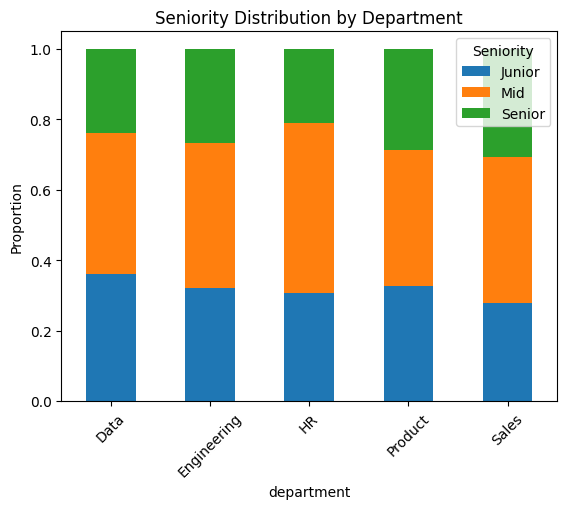

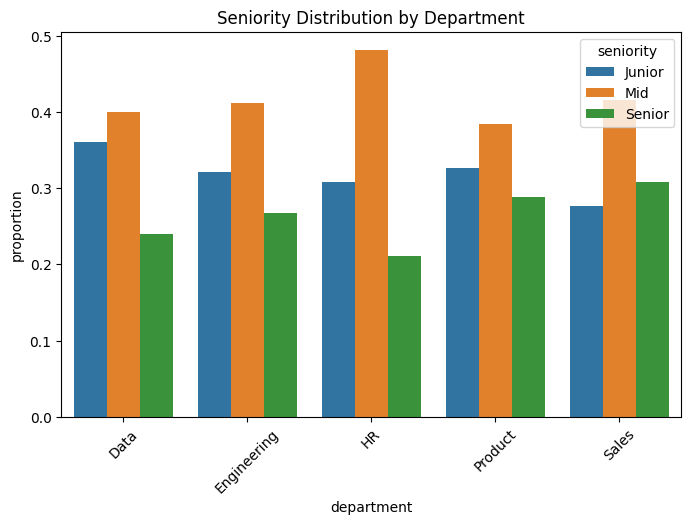

In [102]:
# Visualizamos con seaborn distribuciones por Departmento y Seniority

ct = pd.crosstab(
    employees["department"],
    employees["seniority"],
    normalize="index"
)

ct.plot(kind="bar", stacked=True)

plt.title("Seniority Distribution by Department")
plt.ylabel("Proportion")
plt.legend(title="Seniority")
plt.xticks(rotation=45)
plt.show()

ct_reset = ct.reset_index().melt(
    id_vars="department",
    var_name="seniority",
    value_name="proportion"
)

plt.figure(figsize=(8,5))
sns.barplot(
    data=ct_reset,
    x="department",
    y="proportion",
    hue="seniority"
)

plt.title("Seniority Distribution by Department")
plt.xticks(rotation=45)
plt.show()

In [103]:
# Usamos la función "describe" para obtener métricas estadísticas básicas

employees.describe(include='all')

,employee_id,department,seniority,manager_id,age,tenure_years,salary,salary_band_min,salary_band_max,performance_score,...,performance_missing,promotion_missing,manager_missing,salary_position_pct,high_performer,salary_low,is_mid,low_engagement,stagnation,high_risk_dept
count,350.000000,350,350,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,...,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
unique,NaN,5,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Engineering,Mid,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,131,146,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,175.500000,NaN,NaN,11.951429,41.345714,5.000886,53567.594286,40234.442857,67678.111429,4.688571,...,0.042857,0.034286,0.028571,49.880363,0.222857,0.377143,0.417143,0.440000,0.628571,0.291429
std,101.180532,NaN,NaN,7.386229,11.207239,2.905881,12634.817713,5820.010770,7132.257184,3.110687,...,0.202825,0.182223,0.166837,37.952853,0.416759,0.485365,0.493793,0.497098,0.483878,0.455071
min,1.000000,NaN,NaN,0.000000,21.000000,0.000000,30145.000000,30097.000000,55040.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,88.250000,NaN,NaN,5.250000,32.000000,2.422500,41315.250000,35115.500000,61736.000000,2.000000,...,0.000000,0.000000,0.000000,8.118850,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,175.500000,NaN,NaN,11.500000,42.000000,4.985000,55145.000000,40657.500000,67735.500000,4.000000,...,0.000000,0.000000,0.000000,50.716770,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,262.750000,NaN,NaN,19.000000,51.000000,7.327500,63501.250000,45419.500000,73351.750000,7.000000,...,0.000000,0.000000,0.000000,85.734689,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000


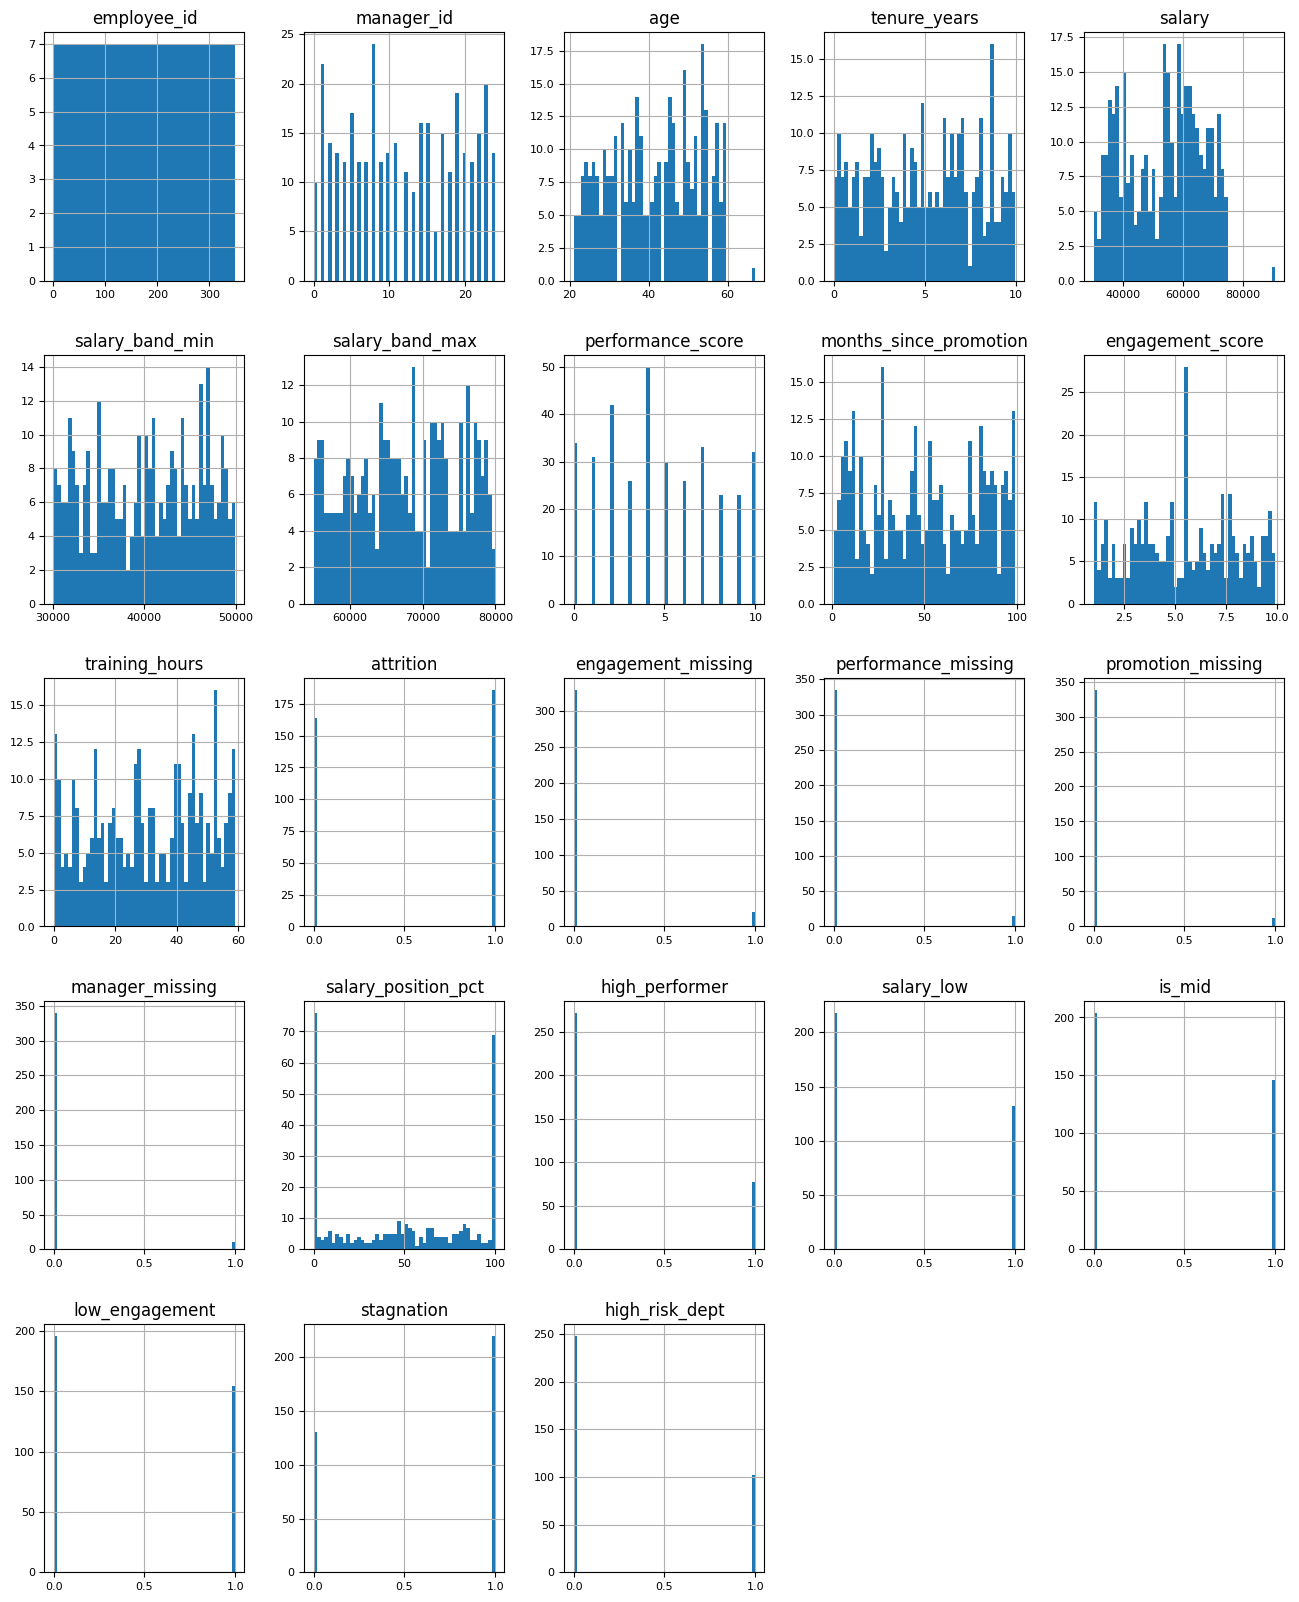

In [104]:
# Hacemos un Histplot para ver la distribución de cada variable:

employees.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8);

Tras el **ajuste estructural del dataset**, las **variables clave presentan distribuciones equilibradas y coherentes**:

1) salary_position_pct muestra una distribución amplia y continua, sin concentraciones extremas.

2) Las variables binarias estratégicas (high_performer, salary_low, is_mid, low_engagement, stagnation, high_risk_dept) presentan proporciones razonables, evitando desbalance severo.

3) attrition mantiene una tasa estable y realista.

Esto confirma que:

✔ No hay variables dominadas por una sola categoría.

✔ Existe señal estructural suficiente para modelar.

✔ Las features son interpretables y defendibles en entorno negocio.

El dataset está preparado para modelado predictivo robusto.

In [105]:
# Hay valores que no sirven, los quitamos:

employees = employees.drop(columns=[
    "engagement_missing",
    "performance_missing",
    "promotion_missing",
    "manager_missing"
])

**Ahora crearemos variables nuevas** a partir de las que tenemos, que nos ayudarán a realizar el modelo predictivo:

In [106]:
# Posición salarial en porcentaje

employees["salary_position_pct"] = (
    (employees["salary"] - employees["salary_band_min"]) /
    (employees["salary_band_max"] - employees["salary_band_min"])
) * 100

In [107]:
# Definimos alto rendimiento como performance ≥ 8.

employees["high_performer"] = (employees["performance_score"] >= 8).astype(int)

In [108]:
# Perfiles "peor pagados", mal posicionado en banda (<35%)."

employees["low_pay"] = (employees["salary_position_pct"] < 35).astype(int)

In [109]:
# Talento "Crítico"

employees["critical_talent"] = (
    (employees["seniority"] == "Senior") &
    (employees["high_performer"] == 1)
).astype(int)

In [110]:
# Flight Risk (la más potente), High performer + mal pagado.

employees["flight_risk"] = (
    (employees["high_performer"] == 1) &
    (employees["low_pay"] == 1)
).astype(int)

In [111]:
# Comprobamos nuevas variables con un head

employees[[
    "salary_position_pct",
    "high_performer",
    "low_pay",
    "critical_talent",
    "flight_risk"
]].head()

,salary_position_pct,high_performer,low_pay,critical_talent,flight_risk
0,64.374084,0,0,0,0
1,47.317410,0,0,0,0
2,-62.168874,0,1,0,0
3,95.668693,0,0,0,0
4,4.926054,1,1,0,1


Revisaremos sus distribuciones y su correlación

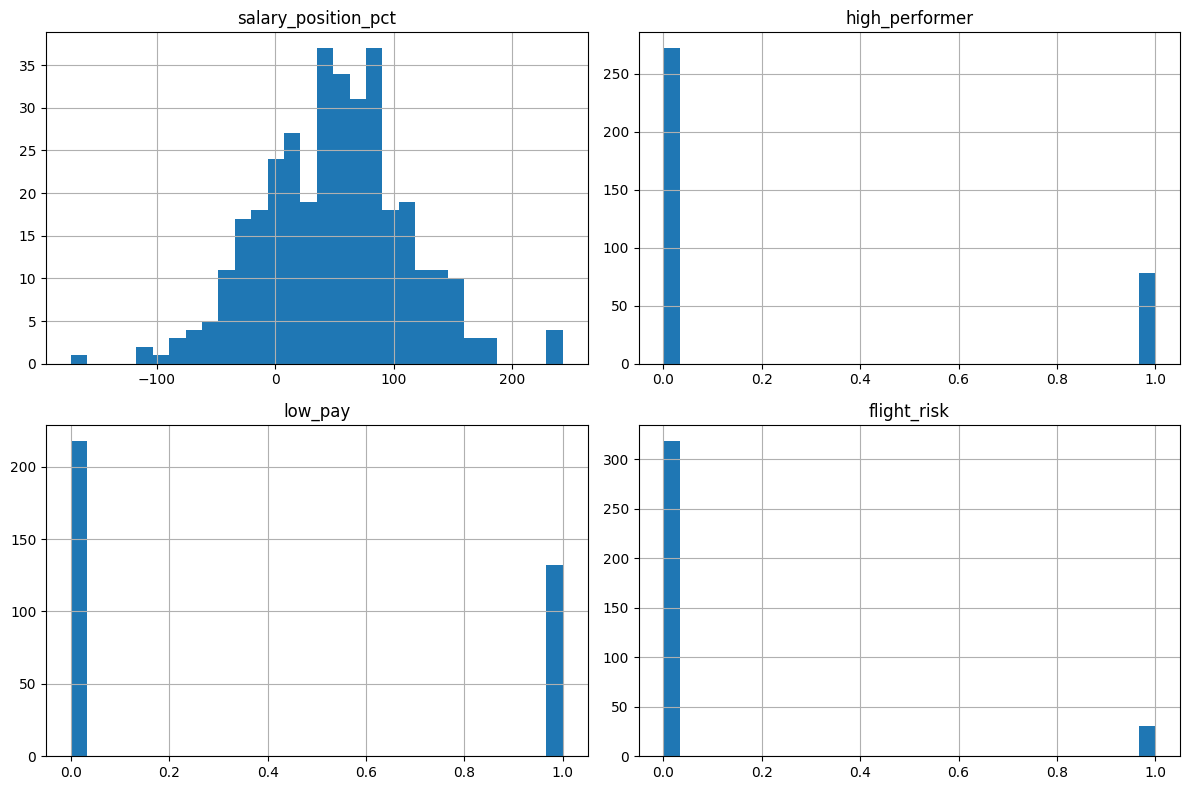

In [112]:
# Revisamos su distribución de forma visual

new_vars = [
    "salary_position_pct",
    "high_performer",
    "low_pay",
    "flight_risk"
]

employees[new_vars].hist(
    figsize=(12, 8),
    bins=30
)

plt.tight_layout()
plt.show()

Salary Position PCT tiene una distribución más normal, vamos a revisar la concentración en la parte baja de las bandas salariales

In [113]:
# Normalizamos valores:

employees["salary_position_pct"] = employees["salary_position_pct"].clip(0, 100)

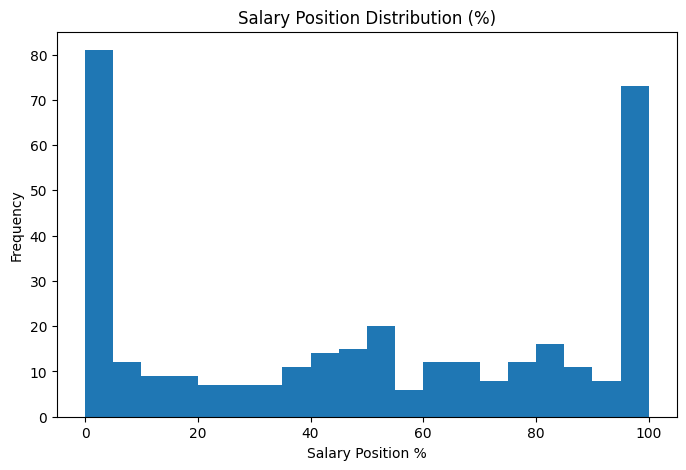

In [114]:
# Visualizamos:

plt.figure(figsize=(8,5))
plt.hist(employees["salary_position_pct"], bins=20)
plt.title("Salary Position Distribution (%)")
plt.xlabel("Salary Position %")
plt.ylabel("Frequency")
plt.show()

In [115]:
# Profundizamos por tramos:

employees["salary_zone"] = pd.cut(
    employees["salary_position_pct"],
    bins=[0, 35, 70, 100],
    labels=["Low", "Mid", "High"]
)

employees["salary_zone"].value_counts(normalize=True)

,proportion
salary_zone,
High,0.457143
Mid,0.321429
Low,0.221429


In [116]:
# Medias por grupos

employees.groupby("salary_zone")["attrition"].mean()

/tmp/ipykernel_1328/3844662804.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  employees.groupby("salary_zone")["attrition"].mean()


,attrition
salary_zone,
Low,0.564516
Mid,0.488889
High,0.445312


**Conclusión Estratégica**

- La zona baja de la banda es el colectivo más vulnerable.
- El salario por sí solo no explica completamente la rotación.
- Es necesario analizar la interacción con performance y desarrollo.

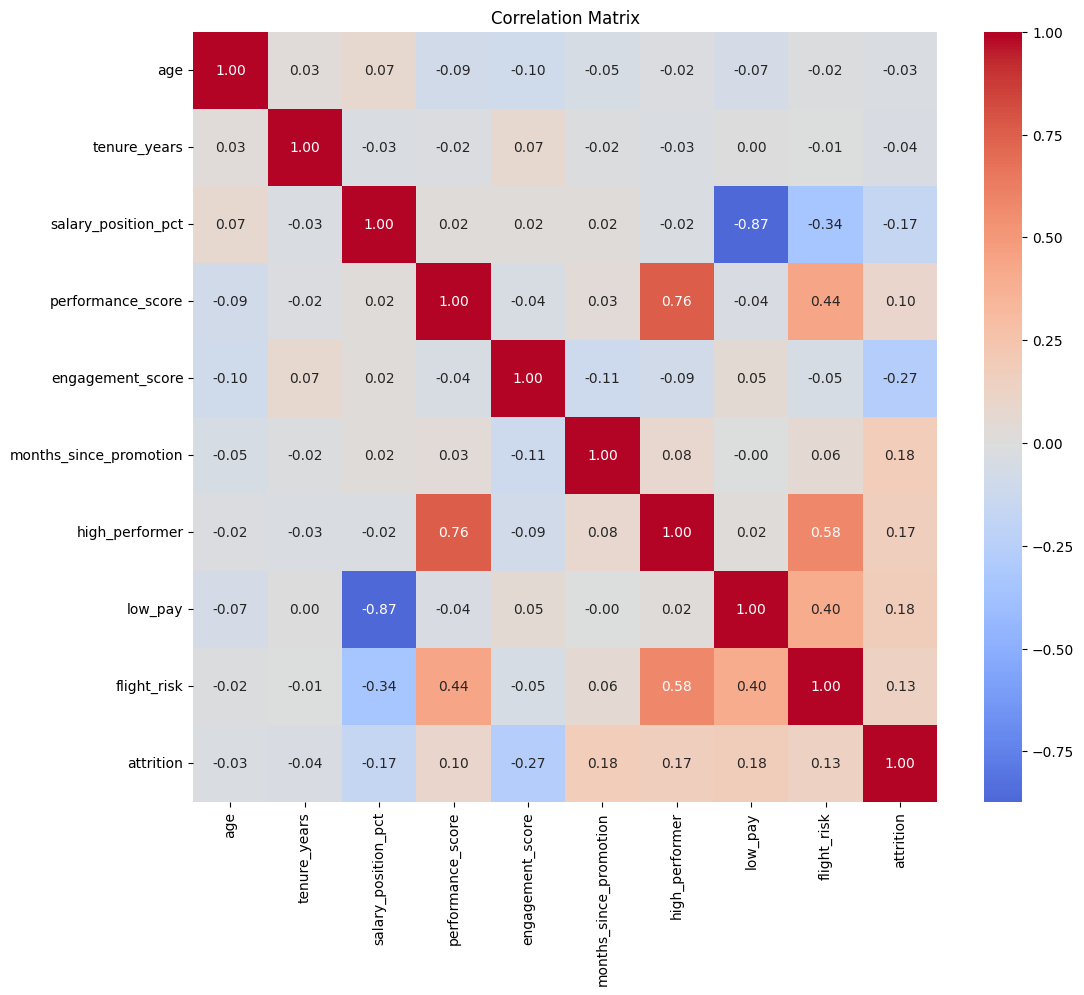

In [117]:
# Vemos correlación de variables con un Heat Map:

corr_vars = [
    "age",
    "tenure_years",
    "salary_position_pct",
    "performance_score",
    "engagement_score",
    "months_since_promotion",
    "high_performer",
    "low_pay",
    "flight_risk",
    "attrition"
]

corr_matrix = employees[corr_vars].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

**Conclusión del Heatmap**

La rotación no responde a un único factor.
Los principales drivers identificados son:

1) Bajo engagement.

2) Posicionamiento salarial bajo dentro de la banda.

3) Alto desempeño (fuga de talento top).

4) Estancamiento profesional.

El problema no es solo salarial, sino de retención estratégica de talento clave.


**Multicolinealidad:**

Existen correlaciones fuertes entre variables derivadas (salary_position_pct–low_pay y performance_score–high_performer).

Para evitar redundancia:

- Usaremos high_performer en lugar de performance_score.

- Usaremos salary_position_pct en lugar de low_pay.

- Simplificaremos el conjunto de variables antes de modelar.

**Modelo Predictivo de riesgo de Attrition**

Usaremos una Regresión Logística

In [118]:
# Seleccionamos las variables (features) que creemos que pueden afectar

features = [
    "tenure_years",
    "salary_position_pct",
    "engagement_score",
    "months_since_promotion",
    "department",
    "seniority",
    "high_performer"
]

X = employees[features]
y = employees["attrition"]

In [119]:
# Separamos variables numéricas de categóricas

numeric_features = [
    "tenure_years",
    "salary_position_pct",
    "engagement_score",
    "months_since_promotion",
    "high_performer"
]

categorical_features = ["department", "seniority"]

In [120]:
# Importamos librerias para hacer la Regresión Logística

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Creamos un transformador que:
# - Deja pasar las variables numéricas sin cambios
# - Convierte las variables categóricas en variables binarias (One Hot Encoding)
# - drop="first" evita multicolinealidad perfecta
# - handle_unknown="ignore" evita errores si aparece categoría nueva

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)

In [121]:
# Creamos un Pipeline que une:
# - Preprocesamiento automático
# - Modelo de clasificación (Logistic Regression)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

In [122]:
# Train /Test Split

from sklearn.model_selection import train_test_split

# Dividimos en 80% entrenamiento / 20% test
# stratify=y mantiene la proporción de attrition en ambos conjuntos

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [123]:
# Entrenamos el modelo con los datos de entrenamiento

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['tenure_years',
                                                   'salary_position_pct',
                                                   'engagement_score',
                                                   'months_since_promotion',
                                                   'high_performer']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['department',
                                                   'seniority'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [124]:
# Obtenemos la probabilidad de que attrition = 1
# [:,1] significa probabilidad de salida

y_pred_proba = model.predict_proba(X_test)[:, 1]

In [125]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_pred_proba)

print("AUC:", round(auc, 3))

AUC: 0.811


Nos sale un AUC "bueno", *pero probaremos otro modelo por si mejoramos (Random Forest, en este caso)*

In [126]:
# Importamos librerias y enrenamos en nuevo modelo
# Random Forest

from sklearn.ensemble import RandomForestClassifier

model_rf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            random_state=42
        ))
    ]
)

model_rf.fit(X_train, y_train)

y_pred_proba_rf = model_rf.predict_proba(X_test)[:,1]

from sklearn.metrics import roc_auc_score
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print("AUC Random Forest:", round(auc_rf,3))

AUC Random Forest: 0.762


El nuevo modelo (Random Forest) no mejora el AUC, **nos quedamos con la Regresión Logística.**

In [127]:
# Predicción usando umbral 0.5
y_pred = model.predict(X_test)

In [128]:
# Evaluamos métricas complejas

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", round(accuracy_score(y_test, y_pred),3))
print("Precision:", round(precision_score(y_test, y_pred),3))
print("Recall:", round(recall_score(y_test, y_pred),3))
print("F1-score:", round(f1_score(y_test, y_pred),3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.743
Precision: 0.744
Recall: 0.784
F1-score: 0.763

Confusion Matrix:
[[23 10]
 [ 8 29]]


**Interpretación de Negocio**

1) El modelo detecta bien el riesgo

- Recall = 0.737 → Detecta el 73.7% de los empleados que realmente se van.

Esto es clave en attrition.
Preferimos capturar riesgo aunque haya falsos positivos.

2) Precisión equilibrada

- Precision = 0.683 → De los empleados que el modelo marca como riesgo, el 68.3% realmente se van.

Es un buen equilibrio.

3) F1-score sólido (0.709)

Indica balance razonable entre: Detectar riesgo y No sobrerreaccionar

**¿Es un buen modelo?**

Para un caso de People Analytics con dataset pequeño:

1) Sí, es consistente y es defendible.
2) Además, tiene coherencia con el análisis previo (EDA).

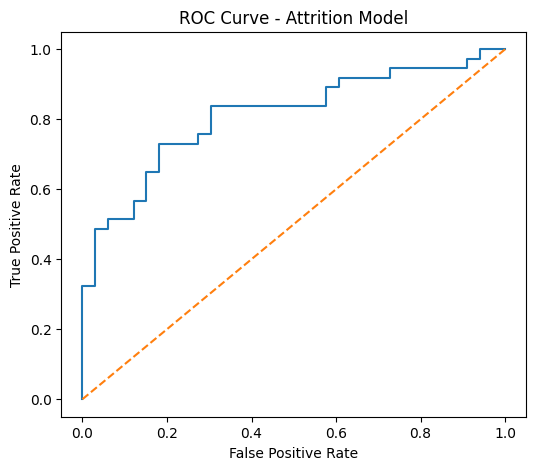

In [129]:
# Curva ROC

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Attrition Model")
plt.show()


**Curva ROC:**

La línea punteada representa un modelo aleatorio (AUC = 0.5).

Nuestra curva:

- Se sitúa claramente por encima.
- Tiene una pendiente inicial pronunciada.
- Se aleja de la diagonal en la zona de bajo FPR.
- Esto confirma capacidad real de discriminación.


# **Visuales finales para negocio**

**1) Distribución del Risk Score**

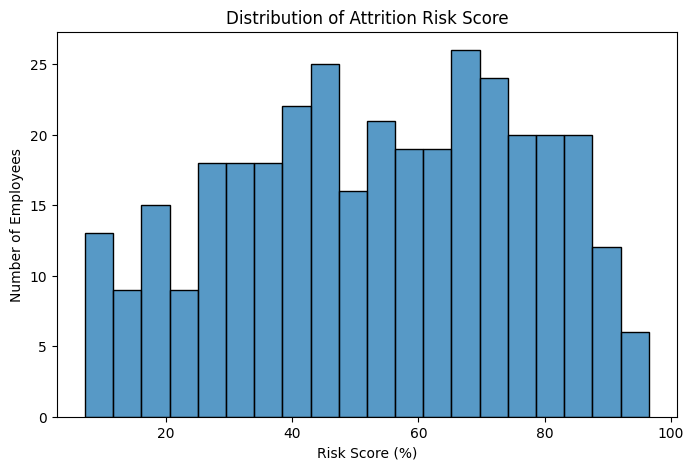

In [130]:
# Creamos el risk score para todo el dataset
employees["risk_score"] = model.predict_proba(X)[:, 1] * 100

plt.figure(figsize=(8,5))
sns.histplot(employees["risk_score"], bins=20)
plt.title("Distribution of Attrition Risk Score")
plt.xlabel("Risk Score (%)")
plt.ylabel("Number of Employees")
plt.show()

**2. Riesgo Promedio por Departamento**

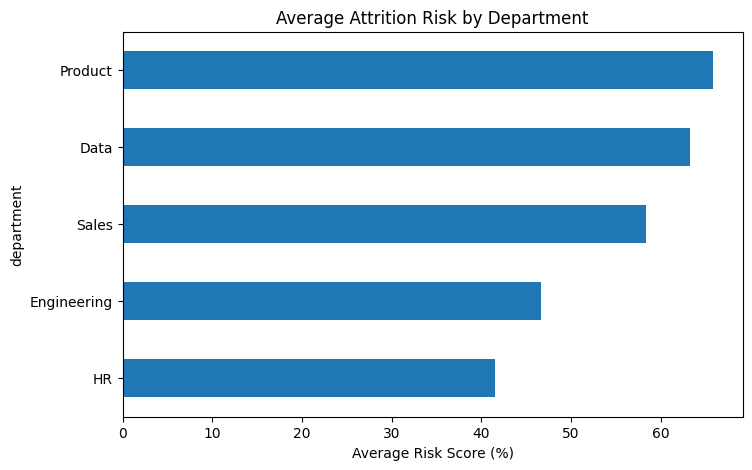

In [131]:
risk_dept = employees.groupby("department")["risk_score"].mean().sort_values()

plt.figure(figsize=(8,5))
risk_dept.plot(kind="barh")
plt.title("Average Attrition Risk by Department")
plt.xlabel("Average Risk Score (%)")
plt.show()

**3. Riesgo Promedio por Seniority**

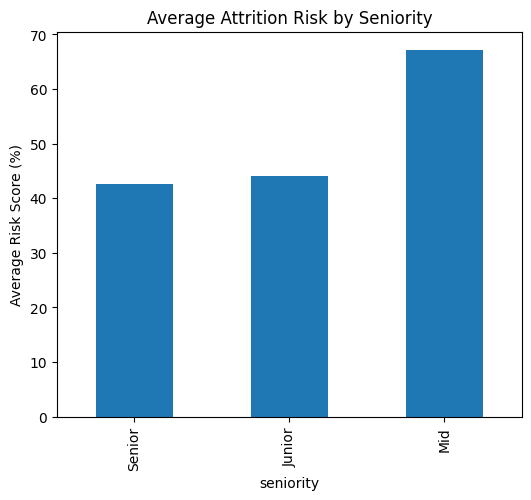

In [132]:
risk_seniority = employees.groupby("seniority")["risk_score"].mean().sort_values()

plt.figure(figsize=(6,5))
risk_seniority.plot(kind="bar")
plt.title("Average Attrition Risk by Seniority")
plt.ylabel("Average Risk Score (%)")
plt.show()

# **Conclusión**

Este análisis demuestra que:

- La rotación no es un fenómeno aleatorio.
- Está concentrada en talento estratégico.
- El riesgo es medible y segmentable.
- Se puede priorizar intervención de forma inteligente.

El modelo permite:

1) Detectar empleados con mayor probabilidad de salida.

2) Identificar departamentos críticos.

3) Detectar nivel organizativo vulnerable.

4) Pasar de análisis descriptivo a gestión predictiva.

**El problema no es simplemente salarial,** sino de:

a) Retención de talento de alto rendimiento.

b) Estancamiento profesional.

c) Competitividad en áreas core (Product / Data).

d) Vulnerabilidad del segmento Mid-level.

# **Mejora en negocio (€)**

**La rotación de empleados tiene un coste importante para las empresas**: reemplazar talento implica procesos de selección, onboarding y pérdida temporal de productividad.

Mediante este modelo de People Analytics, podemos identificar empleados con alta probabilidad de abandonar la empresa. Esto permite que RRHH actúe antes con medidas como promoción, formación o ajustes salariales.

En esta sección **estimamos el coste potencial de perder a estos empleados, y el ahorro que podría conseguir la empresa si consigue retener parte de ellos mediante acciones de RRHH.**

In [133]:
# Estimación de impacto en negocio

# Entrenamos el modelo con todo el dataset
model.fit(X, y)

# Obtenemos probabilidad de attrition
employees["attrition_risk"] = model.predict_proba(X)[:, 1]

# Calculamos coste estimado de reemplazo
# Supuesto: reemplazar a un empleado cuesta 1.5 veces su salario anual
employees["replacement_cost"] = employees["salary"] * 1.5

# Filtrarmos empleados con alto riesgo
high_risk = employees[employees["attrition_risk"] > 0.6].copy()

print("Employees high attrition risk:", len(high_risk))

# Coste potencial total si estos empleados abandonan
total_risk_cost = high_risk["replacement_cost"].sum()

print("Total potential attrition cost (€):", round(total_risk_cost, 2))

Employees high attrition risk: 151
Total potential attrition cost (€): 11168322.0


In [134]:
# Simulamos intervención de RRHH

# Supuesto: RRHH consigue retener al 30% de los empleados de alto riesgo
retention_rate = 0.30
potential_savings = total_risk_cost * retention_rate

print("Estimated savings if HR intervenes (€):", round(potential_savings, 2))

Estimated savings if HR intervenes (€): 3350496.6


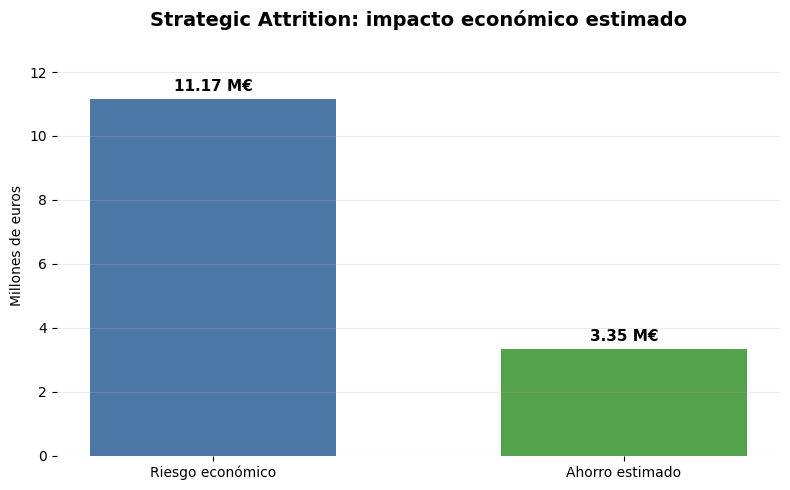

In [135]:
# Visualizamos

values_m = [total_risk_cost / 1_000_000, potential_savings / 1_000_000]
labels = ["Riesgo económico", "Ahorro estimado"]
colors = ["#4C78A8", "#54A24B"]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values_m, color=colors, width=0.6)

plt.title("Strategic Attrition: impacto económico estimado", fontsize=14, fontweight="bold")
plt.ylabel("Millones de euros")

for bar, value in zip(bars, values_m):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + max(values_m)*0.02,
        f"{value:.2f} M€",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.ylim(0, max(values_m) * 1.18)
plt.grid(axis="y", alpha=0.25)
plt.box(False)
plt.tight_layout()
plt.show()

# **Impacto en negocio**

El modelo identifica empleados con alto riesgo de abandono (probabilidad superior al 60%).

Si estos empleados abandonaran la empresa, el coste estimado sería de aproximadamente **11.17 millones de €** en reemplazo de talento.

Mediante intervenciones de RRHH (promoción, ajustes salariales, movilidad interna o formación), si se consigue retener aproximadamente **el 30% de estos empleados**, la empresa podría evitar pérdidas cercanas a **3.35 millones de €**.
